# 🎯 Đánh giá Baseline DeepSeek-OCR


## 1. Cài đặt thư viện


In [1]:
%%capture
# Cài đặt Unsloth và các dependencies
!pip install --no-deps bitsandbytes accelerate xformers peft trl triton cut_cross_entropy unsloth_zoo
!pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
!pip install --no-deps unsloth

# Cài đặt Transformers & TRL đúng version
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

# Thư viện đánh giá và hỗ trợ
!pip install jiwer einops addict easydict torchvision


In [2]:
import os

# Tắt cảnh báo không cần thiết
os.environ["UNSLOTH_WARN_UNINITIALIZED"] = '0'
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("✅ Cấu hình môi trường hoàn tất!")


✅ Cấu hình môi trường hoàn tất!


## 2. Tải và Load Model


In [3]:
import torch
from unsloth import FastVisionModel
from transformers import AutoModel
from huggingface_hub import snapshot_download

# Đường dẫn lưu model trên Kaggle
MODEL_DIR = "/kaggle/working/deepseek_ocr"

# Tải model nếu chưa có
if not os.path.exists(MODEL_DIR):
    print("⏳ Đang tải DeepSeek-OCR từ Hugging Face...")
    snapshot_download("unsloth/DeepSeek-OCR", local_dir=MODEL_DIR)
    print("✅ Tải model hoàn tất!")
else:
    print("✅ Model đã tồn tại tại:", MODEL_DIR)

# Load model với 4-bit quantization (phù hợp GPU T4)
print("\n🔄 Đang load model vào GPU...")
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_DIR,
    load_in_4bit=True,  
    auto_model=AutoModel,
    trust_remote_code=True,
    unsloth_force_compile=True,
    use_gradient_checkpointing="unsloth",
)

# Gắn LoRA adapter (cần cho việc sử dụng model)
model = FastVisionModel.get_peft_model(
    model,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("✅ Load model thành công!")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2025-12-26 17:44:40.749381: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766771080.771496     778 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766771080.778597     778 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766771080.796319     778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766771080.796339     778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766771080.796342     778 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not import trl.trainer.alignprop_trainer: Failed to import trl.trainer.alignprop_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Failed to import diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion because of the following error (look up to see its traceback):
Failed to import diffusers.loaders.ip_adapter because of the following error (look up to see its traceback):
/usr/local/lib/python3.12/dist-packages/xformers/flash_attn_3/_C.so: undefined symbol: _ZNK3c106SymInt22maybe_as_int_slow_pathEv
Unsloth: Could not import trl.trainer.ddpo_trainer: Failed to import trl.trainer.ddpo_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Failed to impo

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


✅ Model đã tồn tại tại: /kaggle/working/deepseek_ocr

🔄 Đang load model vào GPU...
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2025.12.9: Fast Deepseekocr patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at /kaggle/working/deepseek_ocr and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Unsloth: Making `model.base_model.model.model` require gradients
✅ Load model thành công!


## 3. Chuẩn bị hàm đánh giá


In [4]:
import json
import jiwer
import pandas as pd
from tqdm.notebook import tqdm
from PIL import Image
import shutil
import os

# Tạo thư mục output cho kết quả inference
OUTPUT_DIR = "/kaggle/working/baseline_output"
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def compute_cer(ground_truth, prediction):
    """
    Tính Character Error Rate giữa ground truth và prediction.
    CER = (S + D + I) / N với S=substitutions, D=deletions, I=insertions, N=số ký tự ground truth
    """
    # Chuẩn hóa text
    gt = ground_truth.strip().lower()
    pred = prediction.strip().lower()
    
    # Xử lý edge cases
    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    
    return jiwer.cer(gt, pred)

def run_inference_on_dataset(data_root, num_samples=None):
    """
    Chạy inference trên dataset và tính metrics
    
    Args:
        data_root: Đường dẫn thư mục chứa dữ liệu test (cấu trúc folder-based)
        num_samples: Số mẫu cần đánh giá (None = toàn bộ)
    
    Returns:
        DataFrame kết quả, CER trung bình, số mẫu đã đánh giá
    """
    print(f"📂 Đang đọc dữ liệu từ: {data_root}")
    
    if not os.path.exists(data_root):
        print(f"❌ Thư mục không tồn tại: {data_root}")
        return None, None, 0
    
    # Thu thập tất cả mẫu từ các thư mục con
    all_samples = []
    try:
        subfolders = sorted([f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))],
                          key=lambda x: int(x) if x.isdigit() else x)
    except:
        subfolders = sorted([f for f in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, f))])

    for folder_name in subfolders:
        folder_path = os.path.join(data_root, folder_name)
        label_file = os.path.join(folder_path, "label.json")

        if not os.path.exists(label_file):
            continue

        try:
            with open(label_file, 'r', encoding='utf-8') as f:
                labels = json.load(f)

            for img_name, text in labels.items():
                img_path = os.path.join(folder_path, img_name)
                if os.path.exists(img_path):
                    all_samples.append({
                        "image": img_path,
                        "text": text
                    })
        except:
            continue
    
    # Giới hạn số mẫu nếu cần
    if num_samples is not None:
        all_samples = all_samples[:num_samples]
    
    print(f"🚀 Bắt đầu inference trên {len(all_samples)} mẫu...")
    
    results = []
    total_cer = 0.0
    processed = 0
    instruction = "<image>\nFree OCR. "
    
    for sample in tqdm(all_samples, desc="Processing"):
        try:
            img_path = sample["image"]
            ground_truth = sample["text"]
            
            # Tạo đường dẫn output riêng cho từng ảnh
            folder_name = os.path.basename(os.path.dirname(img_path))
            img_name = os.path.basename(img_path)
            out_path = os.path.join(OUTPUT_DIR, folder_name, img_name)
            
            # Chạy inference
            model.infer(
                tokenizer,
                prompt=instruction,
                image_file=img_path,
                output_path=out_path,
                base_size=1024,
                image_size=640,
                crop_mode=True,
                save_results=True,
                test_compress=False
            )
            
            # Đọc kết quả prediction
            result_file = os.path.join(out_path, "result.mmd")
            prediction = ""
            if os.path.exists(result_file):
                with open(result_file, 'r', encoding='utf-8') as f:
                    prediction = f.read().strip()
            
            # Tính CER
            cer = compute_cer(ground_truth, prediction)
            total_cer += cer
            processed += 1
            
            results.append({
                "image": img_path,
                "ground_truth": ground_truth,
                "prediction": prediction,
                "cer": cer
            })
            
        except Exception as e:
            print(f"⚠️ Lỗi xử lý: {str(e)[:50]}...")
            continue
    
    avg_cer = total_cer / processed if processed > 0 else 0
    df_results = pd.DataFrame(results)
    
    return df_results, avg_cer, processed

print("✅ Đã chuẩn bị các hàm đánh giá!")

✅ Đã chuẩn bị các hàm đánh giá!


## 4

In [5]:
# Đường dẫn tập test (Cấu trúc folder)
TEST_DATA_ROOT = "/kaggle/input/uit-uwdb-line/UIT_HWDB_line/test_data"

# Chạy đánh giá baseline bằng cách truyền đường dẫn thư mục
df_baseline, avg_cer_baseline, num_samples = run_inference_on_dataset(
    TEST_DATA_ROOT,
    num_samples=None 
)

📂 Đang đọc dữ liệu từ: /kaggle/input/uit-uwdb-line/UIT_HWDB_line/test_data
🚀 Bắt đầu inference trên 201 mẫu...


Processing:   0%|          | 0/201 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
Thứ tháng Bảy năm ngày và mới tháng Đáng Hùng vào năm 1942 với:
===============save results:===============



image: 0it [00:00, ?it/s]

other: 0it [00:00, ?it/s]


...


image: 0it [00:00, ?it/s]

other: 0it [00:00, ?it/s]


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
Nv2, Nv3. Quan trong lí hoa đánh nô lôc hát sức đế kháng điều mình. Do lý nghĩa văn nguyên
===============save results:===============



image: 0it [00:00, ?it/s]

other: 0it [00:00, ?it/s]


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
của các ký thú, và cũng là bản chất của thành công.
===============save results:===============



image: 0it [00:00, ?it/s]

other: 0it [00:00, ?it/s]


In [6]:
# Lưu kết quả ra CSV
RESULTS_FILE = "/kaggle/working/baseline_results.csv"
if df_baseline is not None:
    df_baseline.to_csv(RESULTS_FILE, index=False)
    print(f"💾 Đã lưu kết quả vào: {RESULTS_FILE}")


💾 Đã lưu kết quả vào: /kaggle/working/baseline_results.csv


## 5. Kết quả tổng hợp


In [7]:
# Hiển thị kết quả tổng hợp
print("\n" + "="*50)
print(f"{'📊 KẾT QUẢ ĐÁNH GIÁ BASELINE':^50}")
print("="*50)
print(f"  Số mẫu đánh giá: {num_samples}")
print(f"  Average CER    : {avg_cer_baseline:.4f}")
print(f"  Tỷ lệ lỗi      : {avg_cer_baseline*100:.2f}%")
print("="*50)

# Thống kê chi tiết
if df_baseline is not None:
    print(f"\n📈 Thống kê phân phối CER:")
    print(f"   - Median : {df_baseline['cer'].median():.4f}")
    print(f"   - Std Dev: {df_baseline['cer'].std():.4f}")
    print(f"   - Min CER: {df_baseline['cer'].min():.4f}")
    print(f"   - Max CER: {df_baseline['cer'].max():.4f}")



           📊 KẾT QUẢ ĐÁNH GIÁ BASELINE            
  Số mẫu đánh giá: 201
  Average CER    : 1.1104
  Tỷ lệ lỗi      : 111.04%

📈 Thống kê phân phối CER:
   - Median : 0.3239
   - Std Dev: 10.0171
   - Min CER: 0.0000
   - Max CER: 142.3766


## 6. Trực quan hóa kết quả


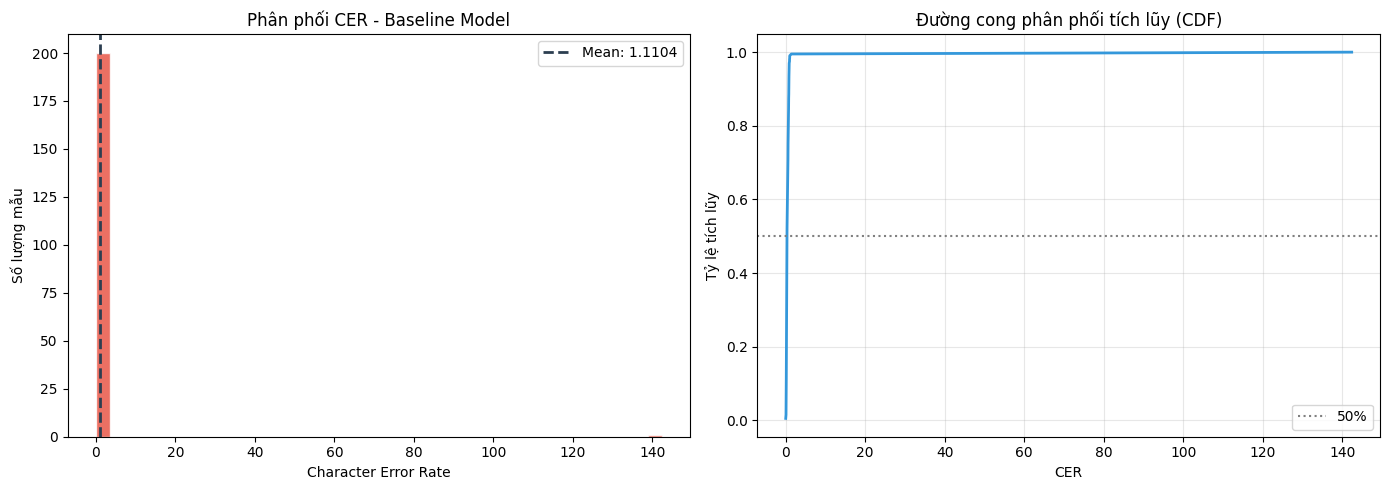

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Histogram phân phối CER
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_baseline['cer'], bins=40, color='#E74C3C', edgecolor='white', alpha=0.8)
axes[0].axvline(avg_cer_baseline, color='#2C3E50', linestyle='--', linewidth=2, 
                label=f'Mean: {avg_cer_baseline:.4f}')
axes[0].set_xlabel('Character Error Rate')
axes[0].set_ylabel('Số lượng mẫu')
axes[0].set_title('Phân phối CER - Baseline Model')
axes[0].legend()

# Cumulative distribution
sorted_cer = np.sort(df_baseline['cer'])
cumulative = np.arange(1, len(sorted_cer) + 1) / len(sorted_cer)
axes[1].plot(sorted_cer, cumulative, color='#3498DB', linewidth=2)
axes[1].set_xlabel('CER')
axes[1].set_ylabel('Tỷ lệ tích lũy')
axes[1].set_title('Đường cong phân phối tích lũy (CDF)')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.5, color='gray', linestyle=':', label='50%')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Hiển thị mẫu kết quả


🌟 TOP 3 MẪU TỐT NHẤT (CER thấp nhất)

📷 Ảnh: 1.jpg
   CER: 0.0000
   ✅ Ground Truth: BẢN CHẤT CỦA THÀNH CÔNG
   🤖 Prediction  : Bản chất của thành công


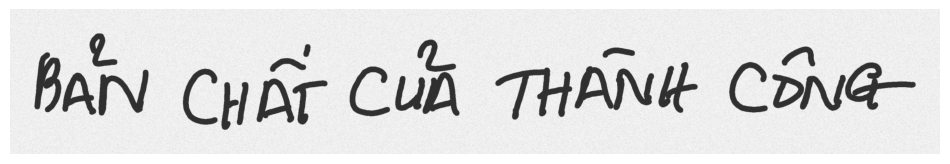

------------------------------------------------------------

📷 Ảnh: 24.jpg
   CER: 0.0392
   ✅ Ground Truth: của các kỳ thi, và cũng là bản chất của thành công.
   🤖 Prediction  : của các ký thú, và cũng là bản chất của thành công.


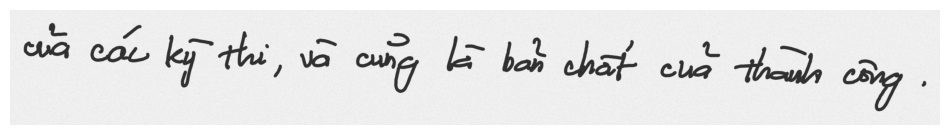

------------------------------------------------------------

📷 Ảnh: 8.jpg
   CER: 0.0732
   ✅ Ground Truth: vi sai trái và những người bao che. Thực hiện tốt các quy định đối với cán bộ lãnh
   🤖 Prediction  : vì sai trai và nhúng người bao che. Thực hiện tốt các quy định đối với cán bộ liên


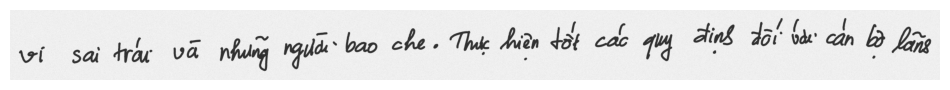

------------------------------------------------------------

🚨 TOP 3 MẪU TỆ NHẤT (CER cao nhất)

📷 Ảnh: 24.jpg
   CER: 142.3766
   ✅ Ground Truth: các nhà đầu tư trong Khu chế xuất Tân Thuận. Vậy thì khi không khắc phục ngay
   🤖 Prediction  : салчын дүнүн кур болгон дүн сүнүн "Тонн Чынын" үнүн чынын дүнүн "Тонн Чынын" үнүн чынум дүнүн "Тонн Чынын" үнүн чындын дүнүн "Тонн Чынын" үнүн дүнүн "Тонн Чынын" үнүн "Тонн Чынын" үнүн "Тоннын" үнүн "Тоннын" үнүн "Тонын" үнүн "Тонын" үнүн "Тоннын" үнүн "Тонын" үнүн "Тоннын" үнүн "Тоның" үнүн "Тоннын" үнүн "Тоңнын" үнүн "Тоңнын" үнүн "тоңнын" үнүн "Тоңнын" үнүн үнүн "Тоңнын" үнүн үнүн үнүн "Тоңнын" үнүн "Тоңын" үнүн "Тоңын" үнүн үнүн үнүн үнүн үнүн үнүрүн үнүн үнүн үнүн үнүн үүнүн үнүн үнүн үнүн үнүн "Тоңнын"үнүн үнүн үнүн үнүн үнүр үнүн үнүн үнүн үнүн үнүүн үнүн үнүн үнүн үнүн үңүн үнүн үнүн үнүн үнүн үчүн үнүн үнүн үнүн үнүн үрүн үнүн үнүн үнүн үнүн "тоңнын"үнүн үнүн үнүн үнүрүн үн үнүн үнүн үнүн үнүн үн үнүн үнүн үнүн үнүрүнүн үнүн үнүн үнүн ү

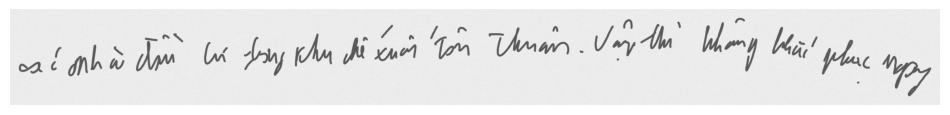

------------------------------------------------------------

📷 Ảnh: 8.jpg
   CER: 1.4167
   ✅ Ground Truth: 330.000 km2)
   🤖 Prediction  : \[ 330.000 \, \text{km}^2 \]


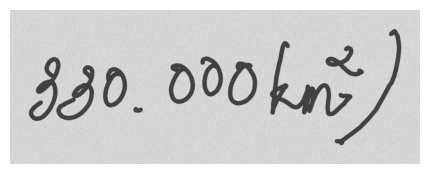

------------------------------------------------------------

📷 Ảnh: 24.jpg
   CER: 1.0000
   ✅ Ground Truth: đất.
   🤖 Prediction  : 书法


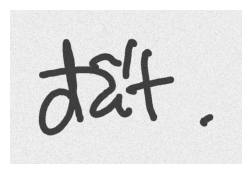

------------------------------------------------------------


In [9]:
def show_sample_predictions(df, n_best=3, n_worst=3):
    """Hiển thị các mẫu prediction tốt nhất và tệ nhất"""
    
    # Mẫu tốt nhất (CER thấp nhất)
    best_samples = df.nsmallest(n_best, 'cer')
    print(f"{'='*60}")
    print(f"🌟 TOP {n_best} MẪU TỐT NHẤT (CER thấp nhất)")
    print(f"{'='*60}")
    
    for idx, row in best_samples.iterrows():
        print(f"\n📷 Ảnh: {os.path.basename(row['image'])}")
        print(f"   CER: {row['cer']:.4f}")
        print(f"   ✅ Ground Truth: {row['ground_truth']}")
        print(f"   🤖 Prediction  : {row['prediction']}")
        
        # Hiển thị ảnh
        if os.path.exists(row['image']):
            img = Image.open(row['image']).convert('RGB')
            plt.figure(figsize=(12, 2))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
        print("-"*60)
    
    # Mẫu tệ nhất (CER cao nhất)
    worst_samples = df.nlargest(n_worst, 'cer')
    print(f"\n{'='*60}")
    print(f"🚨 TOP {n_worst} MẪU TỆ NHẤT (CER cao nhất)")
    print(f"{'='*60}")
    
    for idx, row in worst_samples.iterrows():
        print(f"\n📷 Ảnh: {os.path.basename(row['image'])}")
        print(f"   CER: {row['cer']:.4f}")
        print(f"   ✅ Ground Truth: {row['ground_truth']}")
        print(f"   🤖 Prediction  : {row['prediction']}")
        
        if os.path.exists(row['image']):
            img = Image.open(row['image']).convert('RGB')
            plt.figure(figsize=(12, 2))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
        print("-"*60)

# Hiển thị mẫu
show_sample_predictions(df_baseline, n_best=3, n_worst=3)
